<a href="https://colab.research.google.com/github/Nihat0311/Machine-Learning/blob/main/Realistic_Sales_Revenue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!curl -L -o realistic-sales-revenue-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/drisrarahmad/realistic-sales-revenue-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  137k  100  137k    0     0   239k      0 --:--:-- --:--:-- --:--:--  239k


In [2]:
!unzip /content/realistic-sales-revenue-dataset.zip

Archive:  /content/realistic-sales-revenue-dataset.zip
  inflating: realistic_linear_regression_dataset.csv  


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('/content/realistic_linear_regression_dataset.csv')

In [5]:
df

,ProductCategory,Region,CustomerSegment,IsPromotionApplied,ProductionCost,MarketingSpend,SeasonalDemandIndex,CompetitorPrice,CustomerRating,EconomicIndex,StoreCount,SalesRevenue
0,Furniture,East,High Income,Yes,536.051521,189.277811,1.159611,220.831351,4.035607,146.225757,52,2293.143707
1,Toys,West,High Income,No,352.701361,255.921497,1.545366,467.217175,4.106804,104.261304,35,1640.454368
2,Electronics,South,High Income,No,618.989105,277.399353,1.671902,363.623261,4.021775,77.220752,44,2173.086023
3,Furniture,West,Middle Income,Yes,339.959644,153.557699,1.408244,209.853621,4.148890,128.277455,15,1672.608857
4,Furniture,West,Middle Income,Yes,477.951385,155.814478,2.177301,274.859950,4.913782,111.309643,61,2443.222482
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,Electronics,West,High Income,Yes,517.717323,232.614735,0.975678,322.583207,5.041142,91.441434,17,1936.541701
1996,Clothing,West,Middle Income,No,450.390738,209.679267,1.563159,245.091794,3.720744,127.068979,83,2108.352980
1997,Electronics,South,Low Income,Yes,588.046636,189.616137,1.585797,342.856222,4.449142,130.946380,91,2721.300846
1998,Furniture,South,High Income,No,246.240212,124.049514,0.378380,367.191579,3.848678,92.705192,51,1281.359345


In [6]:
X=df.drop('SalesRevenue',axis=1)
y=df['SalesRevenue'].copy()

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
X_train.shape

(1600, 11)

In [10]:
X_test.shape

(400, 11)

In [11]:
num_features=X_train.select_dtypes(include=[np.number]).columns
cat_features=X_train.select_dtypes(exclude=[np.number]).columns

In [12]:
num_features

Index(['ProductionCost', 'MarketingSpend', 'SeasonalDemandIndex',
       'CompetitorPrice', 'CustomerRating', 'EconomicIndex', 'StoreCount'],
      dtype='object')

In [13]:
cat_features

Index(['ProductCategory', 'Region', 'CustomerSegment', 'IsPromotionApplied'], dtype='object')

In [14]:
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression

In [15]:
num_pipeline=Pipeline([
    ('impute',SimpleImputer(strategy='median')),
    ('scale',StandardScaler())

])

cat_pipeline=Pipeline([
    ('impute',SimpleImputer(strategy='constant',fill_value='missing')),
    ('onehot',OneHotEncoder(sparse_output=False,handle_unknown='ignore'))
])

transformer=ColumnTransformer([
    ('num',num_pipeline,num_features),
    ('cat',cat_pipeline,cat_features)
],remainder='passthrough')

full_pipeline=Pipeline([
    ('transformer',transformer),
    ('estimator',LinearRegression())
])

In [16]:
full_pipeline.fit(X_train,y_train)

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  Index(['ProductionCost', 'MarketingSpend', 'SeasonalDemandIndex',
       'CompetitorPrice', 'CustomerRating', 'EconomicIndex', 'StoreCount'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['ProductCategory', 'Region', 'CustomerSegment', 'IsPromotionApplied'], dtype='object'))])),
                ('estimator', LinearRegression())])

In [17]:
full_pipeline.score(X_train,y_train)

0.9206255759510036

In [18]:
full_pipeline.score(X_test,y_test)

0.9287313515089997

In [19]:
y_pred=full_pipeline.predict(X_test.iloc[[10]])
y_pred

array([2274.7338941])

In [20]:
y_test.iloc[[10]]

,SalesRevenue
56,2441.29349


In [21]:
y_prediction=full_pipeline.predict(X_test)

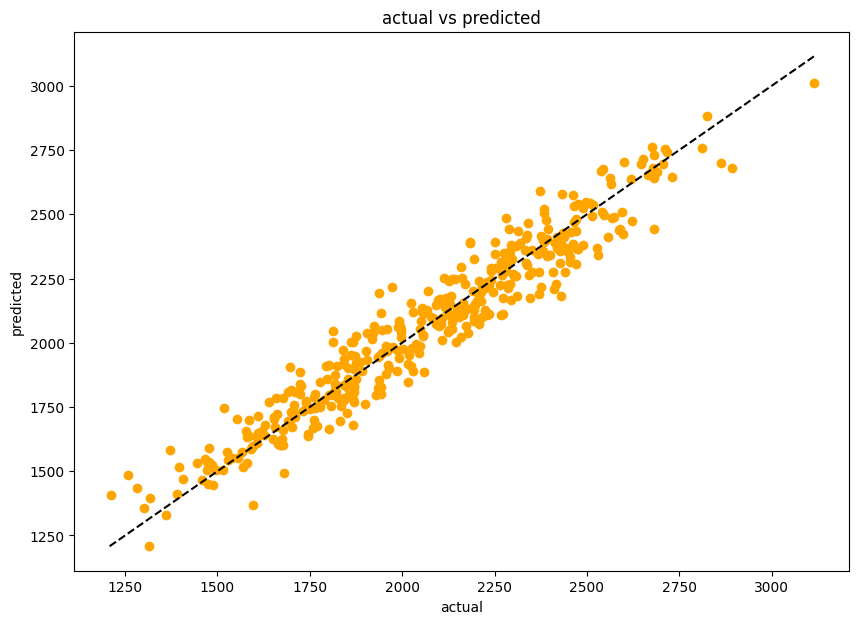

In [22]:
plt.figure(figsize=(10,7))
plt.scatter(y_test,y_prediction,color='orange')
plt.xlabel('actual')
plt.ylabel('predicted')
plt.title('actual vs predicted')

min_val=min(y_test.min(),y_prediction.min())
max_val=max(y_test.max(),y_prediction.max())

plt.plot([min_val,max_val],[min_val,max_val],'--k')
plt.show()

In [23]:
df.describe()

,ProductionCost,MarketingSpend,SeasonalDemandIndex,CompetitorPrice,CustomerRating,EconomicIndex,StoreCount,SalesRevenue
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,499.969606,201.273420,1.484039,299.586427,3.999551,100.220798,48.674500,2072.857450
std,98.840116,49.953760,0.503743,81.524787,0.497141,19.176983,28.940548,346.007903
min,129.120339,46.777157,-0.527025,46.020085,2.449741,36.004789,1.000000,1094.518587
25%,434.452593,167.001091,1.150430,241.267538,3.656696,87.297706,23.000000,1808.106571
50%,500.600031,201.052487,1.485411,301.346897,3.985916,99.951705,49.000000,2068.173855
75%,566.588504,235.146602,1.826129,355.093381,4.338487,112.597996,74.000000,2341.223175
max,865.770180,379.973339,3.046715,552.443030,5.550593,164.320403,99.000000,3115.114292


In [24]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,root_mean_squared_error

In [25]:
y_pred=full_pipeline.predict(X_test)
y_pred[:5]

array([2477.16950135, 2052.75729687, 2166.44215072, 1469.66343313,
       2011.93729054])

In [26]:
mea=mean_absolute_error(y_test,y_pred) # outliere qarsi davamli
mea

73.46715789152593

In [27]:
73.46715789152593/2072.857450  #cavab 0,03 <5 cox ela , 5-10 arasi yaxsi , 10-20 duzeldile biler ,20> berbead

0.035442455481695535

In [28]:
mse=mean_squared_error(y_test,y_pred)
mse # for operation

8560.786330140812

In [29]:
rsme=root_mean_squared_error(y_test,y_pred) # outliere qarsi hessas
rsme # for human

92.52451745424459

In [30]:
92.52451745424459/2072.857450


0.04463621820894852

In [31]:
r2=r2_score(y_test,y_pred)
r2

0.9287313515089997

In [32]:
residuals=y_test-y_pred
residuals

,SalesRevenue
1860,-89.215501
353,-93.321383
1333,-69.071657
905,-64.133789
1289,96.064321
...,...
965,-147.635608
1284,-21.367583
1739,33.646028
261,213.075376


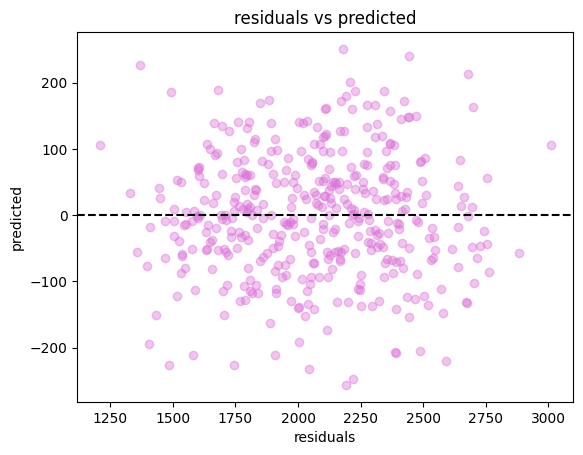

In [33]:
plt.scatter(y_pred,residuals,color='orchid',alpha=0.4)
plt.axhline(0,color='black',linestyle='--')
plt.xlabel('residuals')
plt.ylabel('predicted')
plt.title('residuals vs predicted')
plt.show()

In [34]:
np.random.seed(42)
m=100
x=6*np.random.rand(m,1)-3
y=0.5*x **2 + x+2+np.random.rand(m,1)

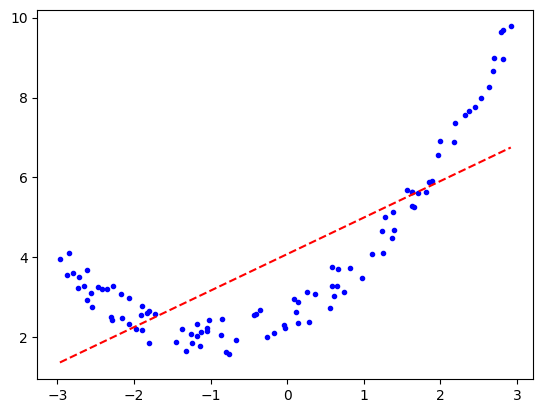

0.5884639595731203

In [35]:
model=LinearRegression()
model.fit(x,y)
y_pred=model.predict(x)
plt.plot(x,y,'b.')
x_line=np.linspace(x.min(),x.max(),m).reshape(-1,1)
y_line=model.predict(x_line)
plt.plot(x_line,y_line,color='red',linestyle='--')
plt.show()

r2_score(y,y_pred)

In [36]:
from sklearn.preprocessing import PolynomialFeatures

In [37]:
# y=w1*x1+x2*w2+w3*x3 +b

In [38]:
x=[
    [1],
    [2],
    [-3]
]

In [39]:
poly=PolynomialFeatures(degree=2,include_bias=False)
poly.fit_transform(x)

array([[ 1.,  1.],
       [ 2.,  4.],
       [-3.,  9.]])

In [40]:
np.random.seed(42)
m=100
x=6*np.random.rand(m,1)-3
y=0.5*x **2 + x+2+np.random.rand(m,1)

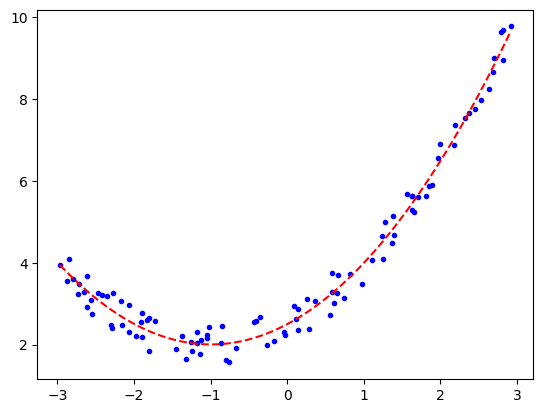

0.9810542445750672

In [41]:
poly=PolynomialFeatures(degree=2,include_bias=False)
x_poly=poly.fit_transform(x)
model.fit(x_poly,y)
y_pred_poly=model.predict(x_poly)
plt.plot(x,y,'b.')

x_line=np.linspace(x.min(),x.max(),m).reshape(-1,1)
x_line_poly=poly.transform(x_line)
y_line_poly=model.predict(x_line_poly)

plt.plot(x_line,y_line_poly,color='red',linestyle='--')
plt.show()
r2_score(y,y_pred_poly)

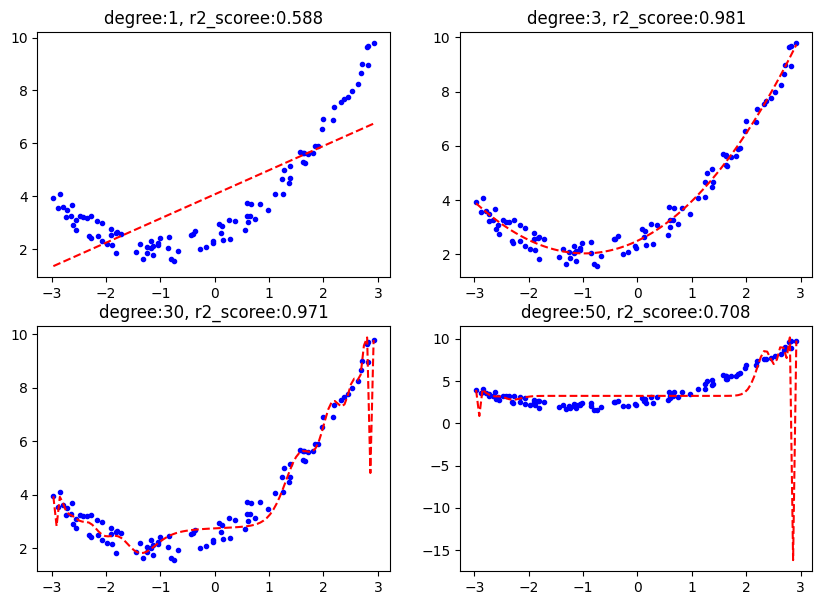

In [44]:
degrees=[1,3,30,50]

fig,axis=plt.subplots(2,2,figsize=(10,7))
for idx , degree in enumerate(degrees):
    ax=axis.flatten()[idx]
    poly=PolynomialFeatures(degree=degree,include_bias=False)
    x_poly=poly.fit_transform(x)
    model.fit(x_poly,y)
    y_pred_poly=model.predict(x_poly)
    ax.plot(x,y,'b.')

    x_line=np.linspace(x.min(),x.max(),m).reshape(-1,1)
    x_line_poly=poly.transform(x_line)
    y_line_poly=model.predict(x_line_poly)

    ax.plot(x_line,y_line_poly,color='red',linestyle='--')
    r2=r2_score(y,y_pred_poly)
    ax.set_title(f'degree:{degree}, r2_scoree:{r2:.3f}')
plt.show()